# ROC Curve and Threshold Analysis using Logistic Regression

## Objective

Build a complete fraud detection evaluation pipeline using **Logistic Regression**.

This notebook demonstrates:

- Loading transaction data
- Splitting the dataset
- Feature Scaling
- Logistic Regression
- Predicting Fraud Probabilities
- ROC Curve
- AUC Score
- Threshold Analysis
- Selecting the Best Threshold

# Problem Statement

A fintech company wants to build a fraud detection system.

Instead of only predicting Fraud or Legitimate transactions, the model should also predict the probability that a transaction is fraudulent.

Using these probabilities, different decision thresholds will be evaluated.

The goal is to minimize missed fraud cases, even if some legitimate transactions are incorrectly flagged.

In [1]:
import pandas as pd
import io

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
# Load Dataset
data_str = """V1,V2,V3,Class
-1.36,0.87,0.23,1
1.19,0.26,0.17,0
0.13,-0.17,-0.45,0
-0.97,1.79,0.86,0
-0.64,-0.34,0.46,1
1.49,1.21,-0.33,0
-0.04,-0.26,0.07,0
0.40,0.96,0.53,0
-0.15,-0.61,-0.23,1
0.22,0.53,-0.39,0
-1.11,0.08,0.74,1
0.65,-0.97,-0.61,0
"""

df = pd.read_csv(io.StringIO(data_str))

df.head()

,V1,V2,V3,Class
0,-1.36,0.87,0.23,1
1,1.19,0.26,0.17,0
2,0.13,-0.17,-0.45,0
3,-0.97,1.79,0.86,0
4,-0.64,-0.34,0.46,1


In [3]:
# Define Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [6]:
# Train Logistic Regression Model
model = LogisticRegression(
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(random_state=42)

In [7]:
# Predict Fraud Probabilities
y_proba = model.predict_proba(
    X_test_scaled
)[:,1]

print(y_proba)

[0.30662262 0.09562007 0.011614  ]


AUC Score : 1.0


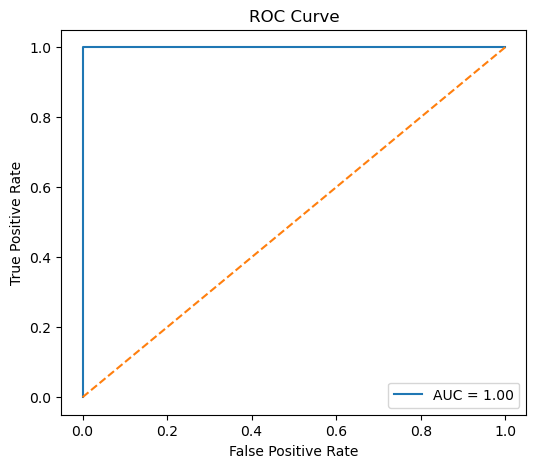

In [8]:
# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

auc_score = roc_auc_score(
    y_test,
    y_proba
)

print("AUC Score :", auc_score)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Threshold Analysis

Evaluate different probability thresholds.

Thresholds:

- 0.1
- 0.2
- 0.3
- 0.4
- 0.5

In [10]:
thresholds_to_try = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
]

print("Threshold Analysis")
print("-"*50)

for t in thresholds_to_try:

    y_pred = (y_proba >= t).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print(
        f"Threshold: {t:.1f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold Analysis
--------------------------------------------------
Threshold: 0.1 | Precision: 1.00 | Recall: 1.00 | F1: 1.00
Threshold: 0.2 | Precision: 1.00 | Recall: 1.00 | F1: 1.00
Threshold: 0.3 | Precision: 1.00 | Recall: 1.00 | F1: 1.00
Threshold: 0.4 | Precision: 0.00 | Recall: 0.00 | F1: 0.00
Threshold: 0.5 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


In [11]:
# Threshold Recommendation
print("""
Recommended Threshold: 0.1

Reason:

The company wants to minimize missed fraud cases.

A lower threshold increases Recall,
allowing the model to detect more fraudulent
transactions.

Although this may increase False Positives,
it is acceptable because the business policy
prioritizes catching fraud over avoiding
incorrect alerts.
""")


Recommended Threshold: 0.1

Reason:

The company wants to minimize missed fraud cases.

A lower threshold increases Recall,
allowing the model to detect more fraudulent
transactions.

Although this may increase False Positives,
it is acceptable because the business policy
prioritizes catching fraud over avoiding
incorrect alerts.



# Conclusion

Workflow

Dataset

↓

Train-Test Split

↓

Feature Scaling

↓

Logistic Regression

↓

Predict Probabilities

↓

ROC Curve

↓

AUC Score

↓

Threshold Analysis

↓

Choose Best Threshold

The recommended threshold is **0.1** because it provides the highest Recall and aligns with the company's fraud detection policy.